<a href="https://colab.research.google.com/github/pearlwitch/UDL-solutions/blob/main/hiv_protease_esm2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HIV-1 Protease - ESM-2: Predição de RMSF
#### *Disciplina: Aprendizado Profundo em Biologia de Sistemas*
#### *Discente: Larissa de Oliveira Bastos, doutoranda da BCS/Fiocruz*

**Objetivo:** Usar o ESM-2 (protein language model) para:
1. Prever flexibilidade por resíduo (RMSF) das variantes WT, MDR-769 e PR20:::


**Pipeline:**
```
Sequência (99 aa) → ESM-2 → embeddings [99×320] → MLP → RMSF predito paralelamente, ESM-2 com MLM head → Δlog p por mutação; e embeddings comparados diretamente via cosine, L2, PCA e atenção para revelar perturbações evolutivas entre variantes.
```


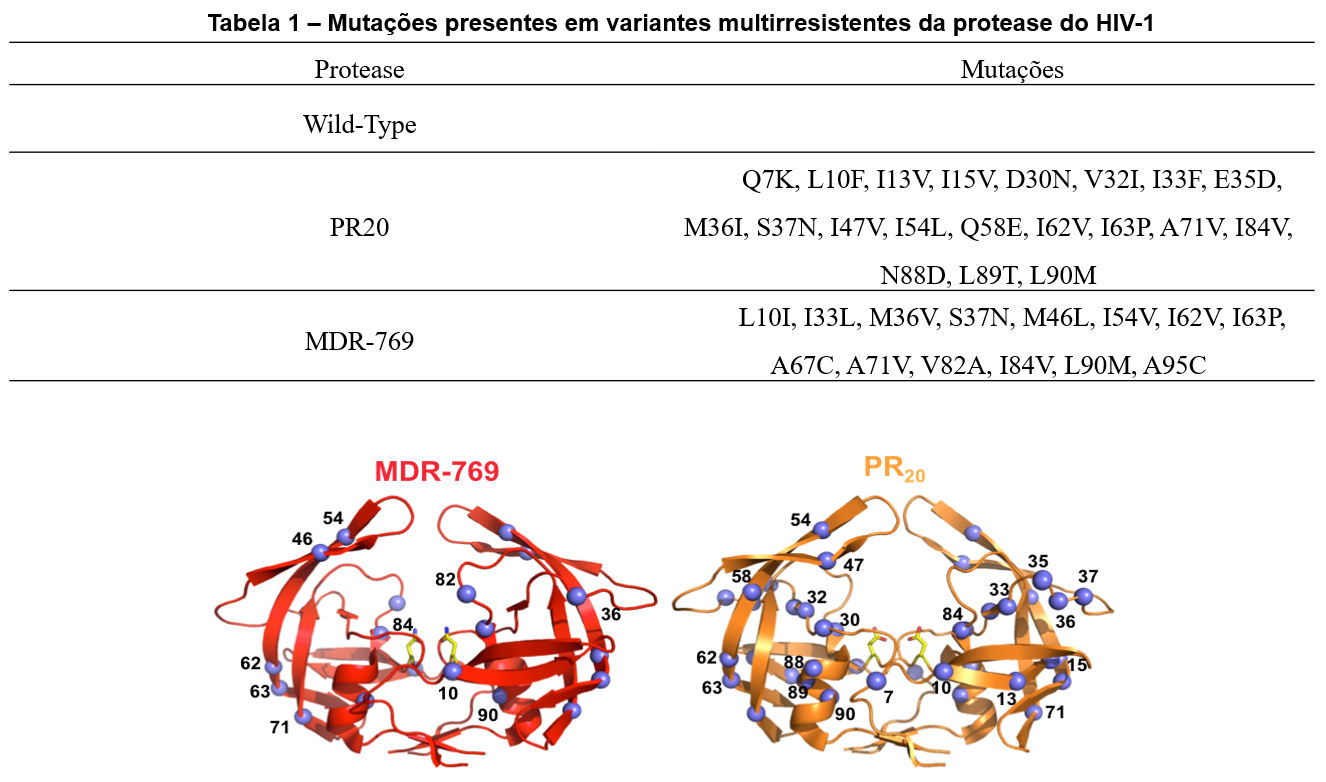


In [ ]:
# Instalar dependências
!pip install fair-esm transformers matplotlib seaborn scikit-learn -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 6.7 MB/s eta 0:00:00


In [ ]:
import json, math, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import r2_score, mean_squared_error
import torch
import torch.nn as nn
from torch.optim import Adam
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
print(f'PyTorch: {torch.__version__}')


Dispositivo: cuda
PyTorch: 2.10.0+cu128


## 1. Dados

RMSF das simulações de DM (média 4 réplicas × 3 µs, em Å). 198 valores por proteína = cadeia A (res. 1–99) + cadeia B (res. 100–198).
Cada cadeia é tratada como amostra independente → 6 amostras no total.


In [ ]:
# Sequências (alinhamento da dissertação)
SEQUENCES = {
    'WT':    'PQITLWQRPLVTIKIGGQLKEALLDTGADDTVIEEMSLPGRWKPKMIGGIGGFIKVRQYDQILIEIAGHKAIGTVLVGPTPVNIIGRNLLTQIGATLNF',
    'MDR769':'PQITLWQRPIVTIKIGGQLKEALLDTGADDTVLEEVNLPGRWKPKLIGGIGGFVKVRQYDQVPIEICGHKVIGTVLVGPTPANVIGRNLMTQIGCTLNF',
    'PR20':  'PQITLWKRPFVTVKGGQLKEALLDTGADNTIFEDINLPGRWKPKMVGGIGGFLKVREYDQVPIEIAGQHKVIGTVLVGPTPVNVIGRDTMTQIGATLNF',
}
for nome, seq in SEQUENCES.items():
    print(f'{nome}: {len(seq)} resíduos')

# Dados do RMSF imbutidos num dicionário
RMSF_RAW = {"WT": {"chain_A": [1.9715, 1.5625, 1.13025, 1.173, 0.86575, 0.9805, 0.94125, 0.81725, 0.67, 0.7595, 0.71, 0.79225, 0.802, 0.90825, 1.13925, 1.7665, 1.716, 1.40125, 1.13875, 0.86975, 0.76575, 0.623, 0.599, 0.59275, 0.5885, 0.60875, 0.69825, 0.67825, 0.75775, 0.89025, 0.69475, 0.622, 0.6945, 0.82925, 1.01775, 1.13575, 1.35275, 1.354, 1.69475, 1.60775, 1.475, 1.26325, 1.19525, 1.31025, 1.2625, 1.46375, 1.54525, 2.10425, 2.67225, 3.21575, 3.1725, 2.6765, 2.303, 1.85725, 1.5255, 1.11625, 0.953, 0.8835, 0.86725, 1.02925, 1.1405, 0.98225, 0.9975, 0.90175, 0.93625, 1.16225, 1.656, 1.69375, 1.4095, 1.29075, 1.1465, 1.131, 1.02675, 0.911, 0.70075, 0.68775, 0.803, 0.99875, 1.15575, 1.04325, 1.1505, 1.02925, 0.76975, 0.60125, 0.545, 0.6085, 0.6735, 0.85375, 0.73075, 0.70725, 0.871, 0.97425, 1.09475, 1.2035, 0.99625, 0.87225, 0.76825, 0.8405, 1.3175], "chain_B": [1.83125, 1.41475, 1.0055, 1.00375, 0.813, 0.896, 0.91625, 0.7965, 0.6845, 0.77275, 0.7035, 0.773, 0.798, 0.88825, 1.0965, 1.63075, 1.6695, 1.32625, 1.08925, 0.835, 0.73475, 0.6055, 0.6065, 0.6145, 0.611, 0.63425, 0.7505, 0.7425, 0.70125, 0.81525, 0.657, 0.62275, 0.6855, 0.83, 1.02075, 1.1315, 1.3325, 1.33475, 1.665, 1.585, 1.45025, 1.25425, 1.1505, 1.26, 1.21675, 1.3825, 1.4355, 1.96275, 2.2965, 2.5685, 2.71275, 2.41475, 2.01525, 1.65625, 1.45775, 1.0865, 0.93725, 0.84625, 0.82725, 0.977, 1.0955, 0.94425, 0.96975, 0.90825, 0.9635, 1.30575, 1.878, 1.94475, 1.59675, 1.38175, 1.16425, 1.10775, 0.98975, 0.84325, 0.668, 0.664, 0.7955, 1.00375, 1.16925, 1.0835, 1.19225, 1.0115, 0.7375, 0.618, 0.551, 0.6105, 0.66275, 0.79675, 0.7475, 0.72825, 0.88, 0.9865, 1.11075, 1.19275, 0.979, 0.8675, 0.7945, 0.895, 1.4555]}, "MDR769": {"chain_A": [1.93425, 1.52675, 1.1415, 1.06875, 0.85125, 0.92925, 0.9965, 0.9175, 0.8005, 0.86, 0.769, 0.80475, 0.836, 0.98475, 1.23975, 1.8425, 1.81925, 1.516, 1.22275, 0.95525, 0.82125, 0.69325, 0.733, 0.75425, 0.827, 0.8905, 0.98725, 0.901, 0.89625, 0.963, 0.771, 0.78525, 0.86525, 1.115, 1.4075, 1.557, 1.78925, 1.691, 1.99125, 2.02875, 1.942, 1.6935, 1.603, 1.763, 1.73875, 2.09975, 2.49725, 3.30925, 4.3105, 5.0815, 5.00425, 4.2995, 3.5045, 2.72525, 2.11975, 1.5505, 1.3145, 1.159, 1.09225, 1.18875, 1.23325, 1.06025, 1.04975, 0.95925, 1.05825, 1.27775, 1.8565, 2.02575, 1.748, 1.409, 1.04975, 1.05, 0.98075, 0.9165, 0.82875, 0.89475, 1.126, 1.4215, 1.673, 1.53325, 1.679, 1.37675, 0.922, 0.7485, 0.6745, 0.73975, 0.81075, 0.94425, 0.79575, 0.78025, 0.96575, 1.07575, 1.1845, 1.2525, 1.02475, 0.897, 0.805, 0.89175, 1.307], "chain_B": [1.6675, 1.308, 1.0015, 0.98025, 0.80175, 0.88275, 0.91075, 0.85575, 0.72275, 0.7915, 0.7425, 0.8075, 0.83875, 0.96925, 1.1915, 1.69025, 1.679, 1.4115, 1.19225, 0.97875, 0.845, 0.70025, 0.69075, 0.685, 0.7155, 0.71625, 0.85675, 0.87425, 0.83275, 0.893, 0.76975, 0.79325, 0.86625, 1.0705, 1.30825, 1.464, 1.8145, 1.8405, 2.2735, 2.335, 2.3315, 2.0975, 2.0245, 2.00725, 1.99475, 2.30975, 2.52875, 3.2915, 4.3015, 4.96875, 4.80975, 4.09275, 3.2365, 2.49125, 1.978, 1.4555, 1.2255, 1.085, 1.02075, 1.078, 1.139, 1.0235, 1.04975, 0.93625, 0.983, 1.161, 1.614, 1.71525, 1.483, 1.259, 1.00675, 1.02575, 0.9565, 0.88225, 0.83275, 0.87725, 1.07025, 1.3285, 1.5545, 1.437, 1.59575, 1.3285, 0.9135, 0.7535, 0.6705, 0.69575, 0.77, 0.89075, 0.775, 0.73375, 0.923, 0.99475, 1.09375, 1.19325, 0.992, 0.9325, 0.8865, 0.963, 1.52325]}, "PR20": {"chain_A": [2.16125, 1.66975, 1.2295, 1.267, 0.94975, 1.0555, 1.018, 0.922, 0.81375, 0.90675, 0.87375, 0.902, 0.853, 0.97975, 1.13825, 1.6615, 1.73, 1.433, 1.1575, 0.923, 0.86175, 0.73275, 0.765, 0.78775, 0.83825, 0.919, 1.01275, 0.9305, 1.022, 0.97375, 0.75375, 0.71175, 0.821, 1.10875, 1.31825, 1.4465, 1.71175, 1.58775, 1.89725, 1.9565, 1.85, 1.62225, 1.56325, 1.66525, 1.60675, 1.8065, 1.87825, 2.34475, 3.12775, 3.57275, 3.72575, 3.29675, 2.7405, 2.18975, 1.8155, 1.3785, 1.20475, 1.141, 1.10275, 1.3115, 1.3465, 1.12075, 1.13075, 1.02625, 1.05925, 1.183, 1.7235, 1.928, 1.6505, 1.43, 1.152, 1.17375, 1.14525, 1.0565, 0.82525, 0.8325, 0.98575, 1.249, 1.55825, 1.415, 1.4735, 1.12225, 0.81575, 0.6925, 0.6595, 0.77475, 0.942, 1.16575, 0.864, 0.9365, 1.298, 1.3215, 1.333, 1.538, 1.3005, 1.10625, 0.99175, 0.99825, 1.42225], "chain_B": [2.058, 1.59375, 1.2195, 1.181, 1.0875, 1.17525, 1.1825, 1.065, 0.849, 0.9175, 0.888, 0.91425, 0.84025, 0.95575, 1.11425, 1.59225, 1.72275, 1.41025, 1.173, 0.976, 0.906, 0.7455, 0.7495, 0.7755, 0.78375, 0.75175, 0.84775, 0.83425, 0.9035, 0.8435, 0.6915, 0.685, 0.7885, 1.0465, 1.2475, 1.3745, 1.62025, 1.53525, 1.956, 2.05475, 1.908, 1.6095, 1.57725, 1.8425, 1.91875, 2.13425, 2.4085, 3.0445, 3.90025, 4.90275, 4.8465, 3.86775, 3.11975, 2.3415, 1.7995, 1.26725, 1.058, 1.00225, 0.98175, 1.20275, 1.234, 1.0095, 1.025, 0.95325, 1.01175, 1.164, 1.73275, 1.91625, 1.639, 1.38675, 1.1095, 1.10175, 1.098, 1.0265, 0.7945, 0.76, 0.9035, 1.1815, 1.463, 1.32925, 1.413, 1.096, 0.804, 0.68375, 0.634, 0.6685, 0.75475, 0.888, 0.73125, 0.79025, 1.04025, 1.087, 1.14425, 1.302, 1.12075, 1.048, 1.0155, 1.08, 1.4475]}}

SAMPLES = []
for proteina in ['WT','MDR769','PR20']:
    for cadeia in ['A','B']:
        rmsf = np.array(RMSF_RAW[proteina][f'chain_{cadeia}'])
        SAMPLES.append({'proteina':proteina, 'cadeia':cadeia, 'rmsf':rmsf})

print(f'\nAmostras: {len(SAMPLES)} (3 proteínas × 2 cadeias)')
print(f'RMSF shape: {SAMPLES[0]["rmsf"].shape}')


WT: 99 resíduos
MDR769: 99 resíduos
PR20: 99 resíduos

Amostras: 6 (3 proteínas × 2 cadeias)
RMSF shape: (99,)


## 2. Análise exploratória


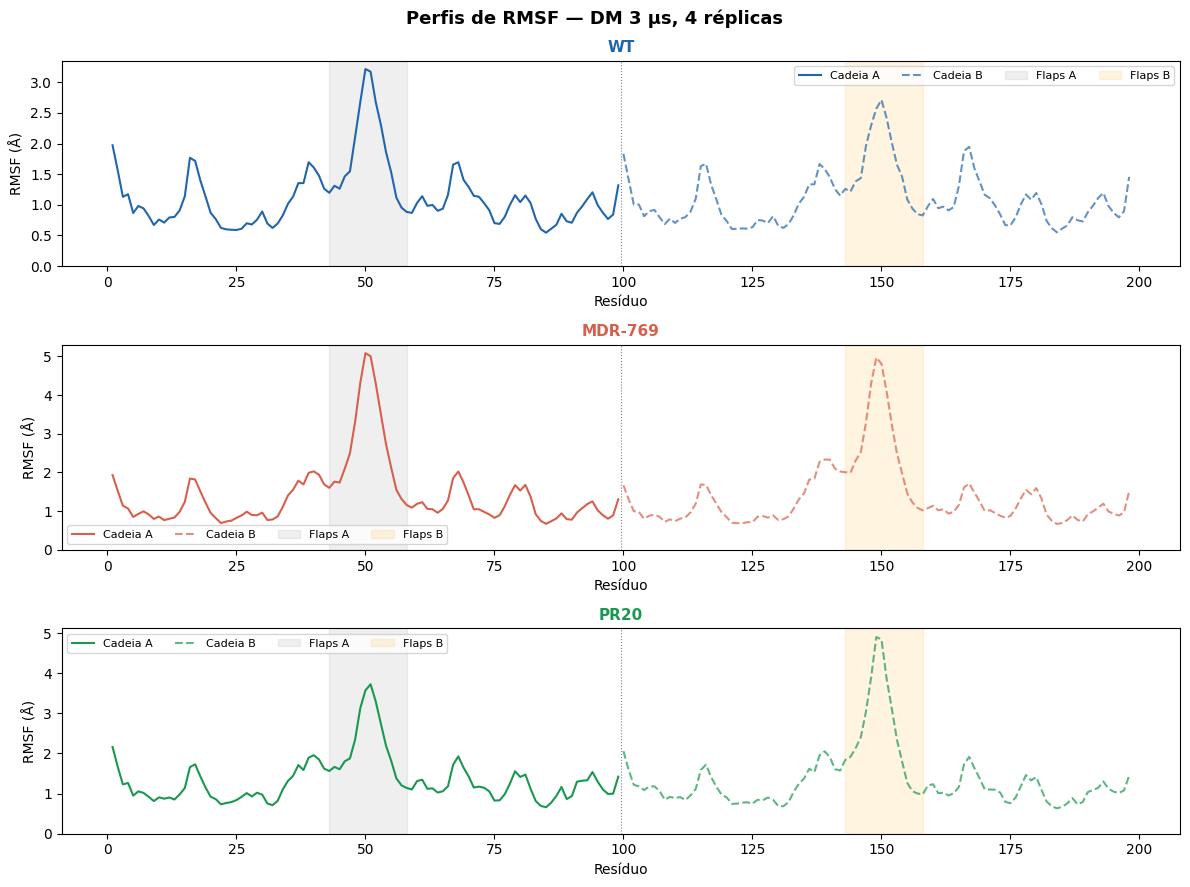

In [ ]:
cores  = {'WT':'#2166ac','MDR769':'#d6604d','PR20':'#1a9850'}
labels = {'WT':'WT','MDR769':'MDR-769','PR20':'PR20'}

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=False)
for ax, proteina in zip(axes, ['WT','MDR769','PR20']):
    rmsf_A = RMSF_RAW[proteina]['chain_A']
    rmsf_B = RMSF_RAW[proteina]['chain_B']
    ax.plot(range(1,100), rmsf_A, color=cores[proteina], label='Cadeia A', lw=1.5)
    ax.plot(range(100,199), rmsf_B, color=cores[proteina], label='Cadeia B', lw=1.5, ls='--', alpha=0.7)
    ax.axvspan(43,58, alpha=0.12, color='gray', label='Flaps A')
    ax.axvspan(143,158, alpha=0.12, color='orange', label='Flaps B')
    ax.axvline(99.5, color='black', lw=0.8, ls=':', alpha=0.5)
    ax.set_title(labels[proteina], fontsize=11, fontweight='bold', color=cores[proteina])
    ax.set_ylabel('RMSF (Å)'); ax.set_xlabel('Resíduo')
    ax.legend(fontsize=8, ncol=4); ax.set_ylim(0, None)
plt.suptitle('Perfis de RMSF — DM 3 µs, 4 réplicas', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


#
#####
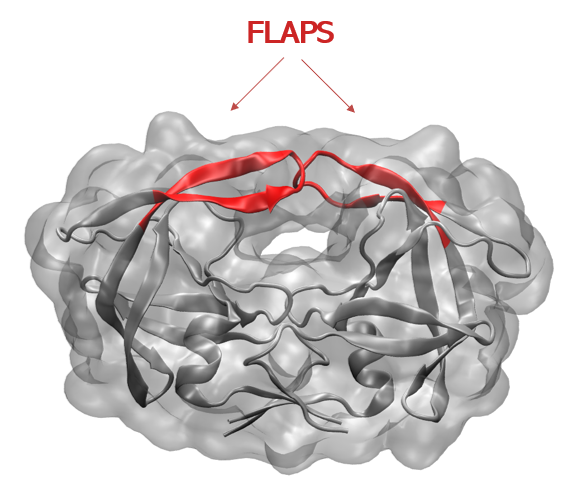

## 3. ESM-2: extração de embeddings

O ESM-2 é treinado por *masked language modeling* em ~250M sequências do UniRef50.
Aprende representações contextuais de aminoácidos que capturam co-evolução e
restrições estruturais (Lin et al., *Science* 2023).

Usamos `esm2_t6_8M_UR50D` (6 camadas, 8M parâmetros, dim=320) - leve para o Colab.
Os embeddings são extraídos **uma vez** e reutilizados no treinamento.


In [ ]:
import esm as esm_lib

print('Carregando ESM-2...')
esm_model, alphabet = esm_lib.pretrained.esm2_t6_8M_UR50D() # carrega o modelo pré-treinado, seus pesos, e o alphabet (dicionário de tokens com 20 aminoacidos e outros especiais)
esm_model = esm_model.to(device).eval()  # eval coloca o modelo em avaliação, desativa o dropout já que nao está treinando
batch_converter = alphabet.get_batch_converter()  # converte sequencia de aminoacidos em tensores de tokens numericos

# Verificar dimensão real dos embeddings
with torch.no_grad():
    _data = [('test', SEQUENCES['WT'])]
    _, _, _tok = batch_converter(_data)
    _out = esm_model(_tok.to(device), repr_layers=[6]) # como o modelo tem 6 camadas, a última está sendo mais processada semanticamente
    EMB_DIM = _out['representations'][6].shape[-1]

print(f'EMB_DIM: {EMB_DIM}')
print(f'Parâmetros: {sum(p.numel() for p in esm_model.parameters()):,}')


Carregando ESM-2...
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t6_8M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t6_8M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D-contact-regression.pt
EMB_DIM: 320
Parâmetros: 7,512,474


In [ ]:
def get_embeddings(sequence, name, layer=6):
    """Embeddings por resíduo da última camada. Remove tokens especiais [CLS] e [EOS]."""
    _, _, tokens = batch_converter([(name, sequence)])
    with torch.no_grad():
        out = esm_model(tokens.to(device), repr_layers=[layer])
    return out['representations'][layer][0, 1:-1, :]  # [L, EMB_DIM]

EMBEDDINGS = {}
for nome, seq in SEQUENCES.items():
    emb = get_embeddings(seq, nome)
    EMBEDDINGS[nome] = emb
    print(f'{nome}: {emb.shape}')


WT: torch.Size([99, 320])
MDR769: torch.Size([99, 320])
PR20: torch.Size([99, 320])


## 4. Treinamento — Leave-One-Out

**Arquitetura MLP (Multi-layer Perceptron):**
```
Input [EMB_DIM] → Linear→ReLU→Dropout(0.2) → Linear→ReLU → Linear → RMSF
```
Opera resíduo a resíduo: cada posição recebe embedding [EMB_DIM] e prediz um escalar.

**LOO:** com 6 amostras, treina em 5 e testa em 1 — repete 6 vezes.


In [ ]:
# Cabeça de predição
class RMSFHead(nn.Module):
    def __init__(self, emb_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(emb_dim, hidden), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(hidden, 64),     nn.ReLU(),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)  # [L]

# Montar dataset
dataset = []
for s in SAMPLES:
    X = EMBEDDINGS[s['proteina']]  # [99, EMB_DIM]
    y = torch.tensor(s['rmsf'], dtype=torch.float32).to(device)
    dataset.append((X, y, s['proteina'], s['cadeia']))

print(f'Dataset: {len(dataset)} amostras')
print(f'X: {dataset[0][0].shape} | y: {dataset[0][1].shape}')


Dataset: 6 amostras
X: torch.Size([99, 320]) | y: torch.Size([99])


In [ ]:
def train_and_eval(train_set, test_sample, epochs=300, lr=1e-3):
    model = RMSFHead(emb_dim=EMB_DIM).to(device)
    opt   = Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    model.train()
    for _ in range(epochs):
        for X, y, *_ in train_set:
            opt.zero_grad()
            loss_fn(model(X), y).backward()
            opt.step()

    model.eval()
    X_t, y_t, prot, cad = test_sample
    with torch.no_grad():
        y_pred = model(X_t).cpu().numpy()
    y_true = y_t.cpu().numpy()

    r2   = r2_score(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r, p = stats.pearsonr(y_true, y_pred)
    return y_true, y_pred, {'R2':r2,'RMSE':rmse,'Pearson_r':r,'p':p,'proteina':prot,'cadeia':cad}

print('Rodando LOO...\n')
resultados, predicoes = [], []

for i in range(len(dataset)):
    train_set   = [dataset[j] for j in range(len(dataset)) if j != i]
    test_sample = dataset[i]
    y_true, y_pred, m = train_and_eval(train_set, test_sample)
    resultados.append(m); predicoes.append((y_true, y_pred, m['proteina'], m['cadeia']))
    print(f'Fold {i+1}/6 | {m["proteina"]} cadeia {m["cadeia"]} | '
          f'R²={m["R2"]:.3f} | RMSE={m["RMSE"]:.3f} Å | r={m["Pearson_r"]:.3f} (p={m["p"]:.2e})')

r2s   = [m['R2'] for m in resultados]
rmses = [m['RMSE'] for m in resultados]
rs    = [m['Pearson_r'] for m in resultados]
print(f'\n── Resumo ──────────────────────────────────')
print(f'R²   {np.mean(r2s):.3f} ± {np.std(r2s):.3f}')
print(f'RMSE {np.mean(rmses):.3f} ± {np.std(rmses):.3f} Å')
print(f'r    {np.mean(rs):.3f} ± {np.std(rs):.3f}')


Rodando LOO...

Fold 1/6 | WT cadeia A | R²=0.967 | RMSE=0.095 Å | r=0.986 (p=1.02e-76)
Fold 2/6 | WT cadeia B | R²=0.910 | RMSE=0.135 Å | r=0.978 (p=8.92e-68)
Fold 3/6 | MDR769 cadeia A | R²=0.964 | RMSE=0.164 Å | r=0.988 (p=4.67e-80)
Fold 4/6 | MDR769 cadeia B | R²=0.973 | RMSE=0.139 Å | r=0.987 (p=4.54e-78)
Fold 5/6 | PR20 cadeia A | R²=0.833 | RMSE=0.240 Å | r=0.973 (p=7.66e-64)
Fold 6/6 | PR20 cadeia B | R²=0.905 | RMSE=0.243 Å | r=0.979 (p=5.22e-69)

── Resumo ──────────────────────────────────
R²   0.925 ± 0.049
RMSE 0.169 ± 0.055 Å
r    0.982 ± 0.005


# Ponto importante

Nos folds onde há um data leakage: testar cadeia B tendo treinado cadeia A da mesma proteína - o R² alto é suspeito.

O modelo basicamente aprendeu "para esse embedding, o RMSF é assim" e reproduziu.

Nos folds onde o leakage é mínimo: testar a PR20 tendo treinado só em WT e MDR-769 - o embedding da PR20 nunca foi visto durante o treino. O R²=0.833 aqui é o número mais honesto do projeto. Ainda alto, mas com 20 mutações é possível tentar considerar esse valor.

## 5. Visualização dos resultados


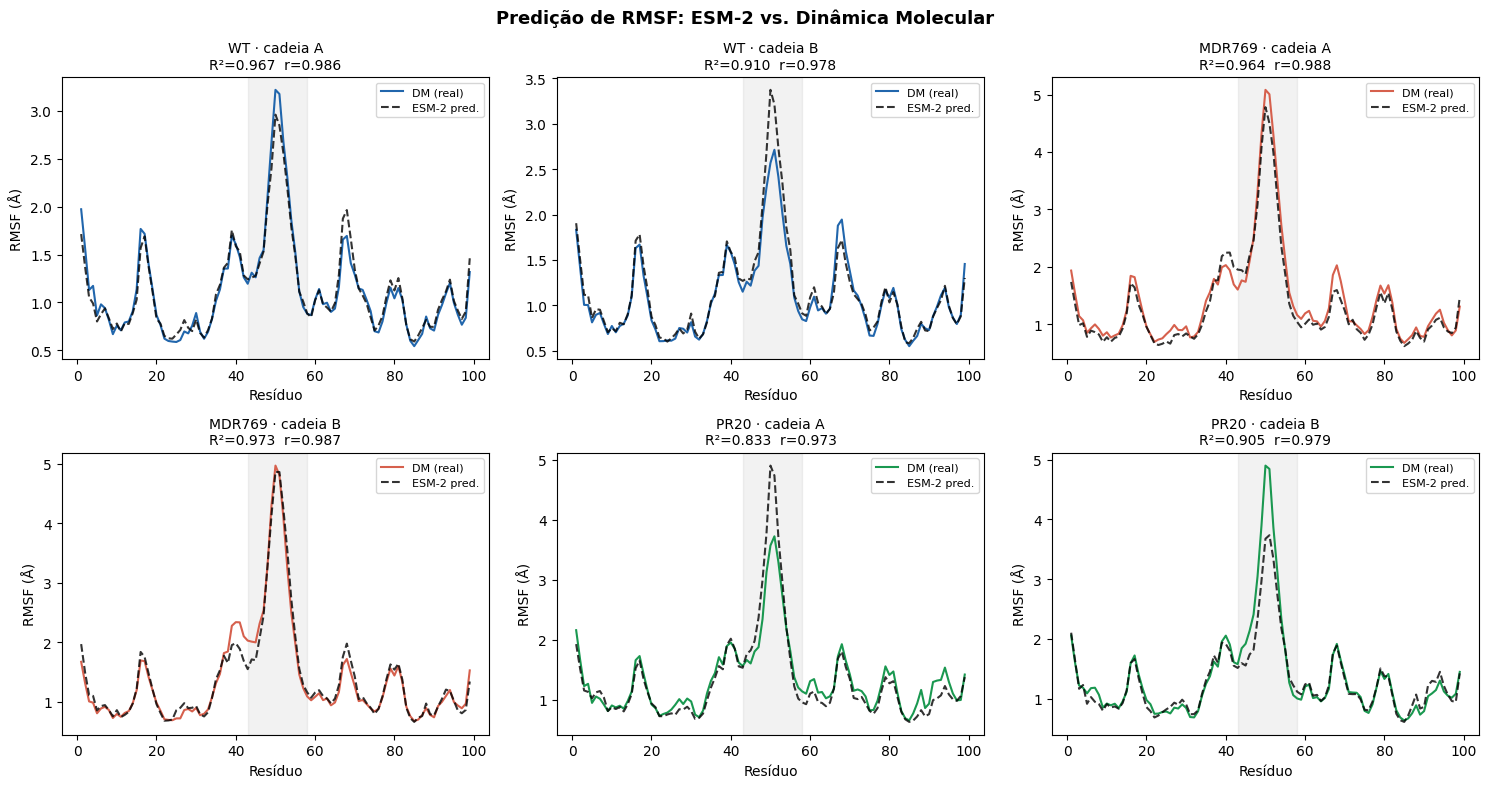

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, (y_true, y_pred, prot, cad) in zip(axes, predicoes):
    cor = cores[prot]
    ax.plot(range(1,100), y_true, color=cor, label='DM (real)', lw=1.5)
    ax.plot(range(1,100), y_pred, color='black', label='ESM-2 pred.', lw=1.5, ls='--', alpha=0.8)
    ax.axvspan(43, 58, alpha=0.1, color='gray')
    r2 = r2_score(y_true, y_pred)
    r, _ = stats.pearsonr(y_true, y_pred)
    ax.set_title(f'{prot} · cadeia {cad}\nR²={r2:.3f}  r={r:.3f}', fontsize=10)
    ax.set_xlabel('Resíduo'); ax.set_ylabel('RMSF (Å)')
    ax.legend(fontsize=8)
plt.suptitle('Predição de RMSF: ESM-2 vs. Dinâmica Molecular', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


Extraindo attention maps...
Attention map shape: (99, 99)


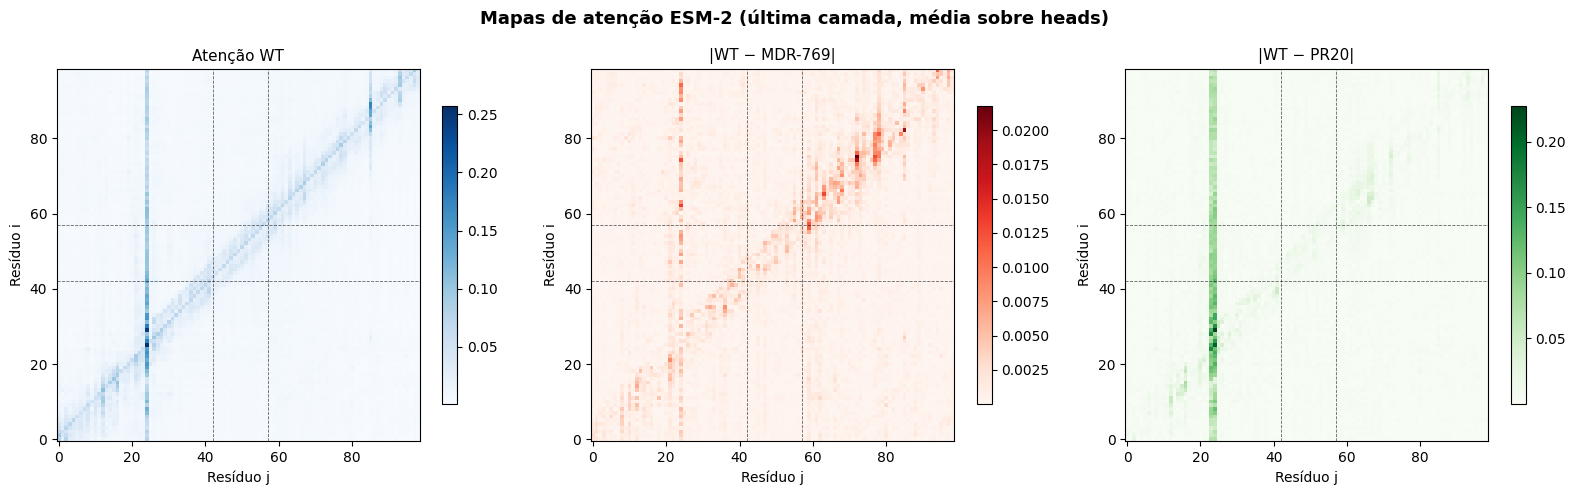

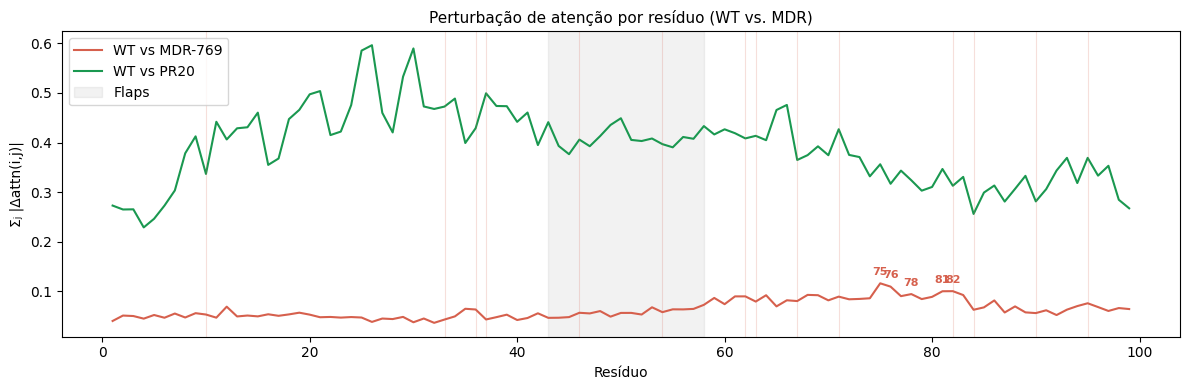

In [ ]:
# ── 8.2 Attention maps — WT vs MDR ───────────────────────────────────────────
#
# O ESM-2 é um transformer: cada camada tem 20 cabeças de atenção que
# representam quais resíduos "olham" para quais outros.
# Extraímos a média das cabeças da última camada → matriz [99×99].
# A diferença |attn_WT - attn_MDR| revela pares de resíduos cujo
# relacionamento evolutivo muda entre as variantes — candidatos a
# comunicação alostérica, comparáveis à sua análise de contatos da DM.

def get_attention_map(sequence, name, layer=-1):
    """
    Retorna mapa de atenção médio (média sobre heads) da camada indicada.
    layer=-1 = última camada. Saída: array [L, L].
    """
    _, _, tokens = batch_converter([(name, sequence)])
    tokens = tokens.to(device)
    with torch.no_grad():
        results = esm_model(tokens, repr_layers=[], need_head_weights=True)
    # results['attentions']: [B, n_layers, n_heads, L+2, L+2]
    attn = results['attentions'][0]           # [n_layers, n_heads, L+2, L+2]
    attn_layer = attn[layer, :, 1:-1, 1:-1]  # [n_heads, L, L] — sem tokens especiais
    return attn_layer.mean(0).cpu().numpy()   # [L, L]

print('Extraindo attention maps...')
attn_wt    = get_attention_map(SEQUENCES['WT'],     'WT')
attn_mdr   = get_attention_map(SEQUENCES['MDR769'], 'MDR769')
attn_pr20  = get_attention_map(SEQUENCES['PR20'],   'PR20')
print(f'Attention map shape: {attn_wt.shape}')

# Diferença absoluta
diff_mdr  = np.abs(attn_wt - attn_mdr)
diff_pr20 = np.abs(attn_wt - attn_pr20)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, mat, title, cmap in [
    (axes[0], attn_wt,   'Atenção WT',             'Blues'),
    (axes[1], diff_mdr,  '|WT − MDR-769|',         'Reds'),
    (axes[2], diff_pr20, '|WT − PR20|',             'Greens'),
]:
    im = ax.imshow(mat, aspect='auto', cmap=cmap, origin='lower')
    # Marcar região dos flaps (res 43-58, índices 42-57)
    for spine_pos in [42, 57]:
        ax.axhline(spine_pos, color='black', lw=0.6, ls='--', alpha=0.6)
        ax.axvline(spine_pos, color='black', lw=0.6, ls='--', alpha=0.6)
    ax.set_xlabel('Resíduo j'); ax.set_ylabel('Resíduo i')
    ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Mapas de atenção ESM-2 (última camada, média sobre heads)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Perfil de perturbação de atenção por resíduo ──────────────────────────────
# Para cada resíduo i: quanto a atenção total saindo de i muda entre variantes
# Soma sobre j: Σ_j |attn_WT(i,j) - attn_MDR(i,j)|

attn_perturb_mdr  = diff_mdr.sum(axis=1)   # [L]
attn_perturb_pr20 = diff_pr20.sum(axis=1)  # [L]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(res, attn_perturb_mdr,  color='#d6604d', lw=1.5, label='WT vs MDR-769')
ax.plot(res, attn_perturb_pr20, color='#1a9850', lw=1.5, label='WT vs PR20')
ax.axvspan(43, 58, alpha=0.1, color='gray', label='Flaps')
for p in mut_mdr:
    ax.axvline(p, color='#d6604d', alpha=0.2, lw=0.8)

# Anotar top 5 resíduos mais perturbados (MDR-769)
top5 = np.argsort(attn_perturb_mdr)[-5:]
for idx in top5:
    ax.annotate(f'{idx+1}', xy=(idx+1, attn_perturb_mdr[idx]),
                xytext=(0, 6), textcoords='offset points',
                ha='center', fontsize=8, color='#d6604d', fontweight='bold')

ax.set_xlabel('Resíduo'); ax.set_ylabel('Σⱼ |Δattn(i,j)|')
ax.set_title('Perturbação de atenção por resíduo (WT vs. MDR)', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()